## Exploración visual de datos con reducción dimensional (PCA y t-SNE)

Este notebook implementa el desafío de reducción dimensional usando el dataset **Iris**.

Pasos:
1. Cargar librerías y dataset.
2. Estandarizar las variables numéricas.
3. Aplicar **PCA** a 2 componentes y graficar.
4. Aplicar **t-SNE** a 2 dimensiones y graficar.
5. Comparar resultados y escribir una breve conclusión.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='whitegrid', context='notebook')

### 1. Cargar y explorar el dataset Iris

In [2]:
iris = load_iris()
X = iris.data          # variables numéricas
y = iris.target        # etiquetas verdaderas
feature_names = iris.feature_names

df = pd.DataFrame(X, columns=feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


### 2. Estandarizar los datos

La estandarización hace que cada variable tenga media 0 y desviación estándar 1, algo importante tanto para PCA como para t-SNE.

In [3]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.90068117,  1.01900435, -1.34022653, -1.3154443 ],
       [-1.14301691, -0.13197948, -1.34022653, -1.3154443 ],
       [-1.38535265,  0.32841405, -1.39706395, -1.3154443 ],
       [-1.50652052,  0.09821729, -1.2833891 , -1.3154443 ],
       [-1.02184904,  1.24920112, -1.34022653, -1.3154443 ]])

### 3. Aplicar PCA (2 componentes) y visualizar

Varianza explicada por componente: [0.72962445 0.22850762]


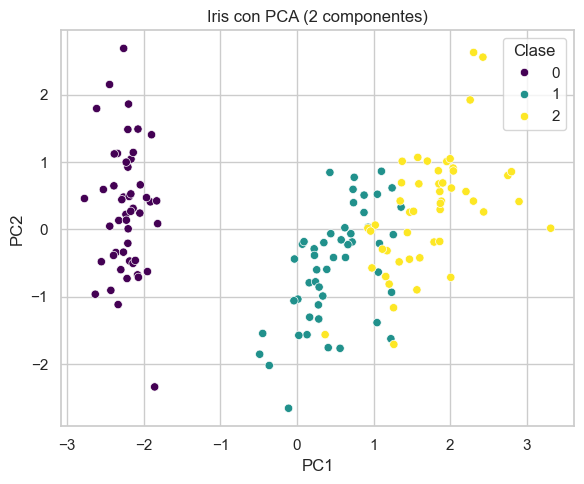

In [4]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print('Varianza explicada por componente:', pca.explained_variance_ratio_)

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='viridis')
plt.title('Iris con PCA (2 componentes)')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Clase')
plt.tight_layout()
plt.show()

### 4. Aplicar t-SNE (2 dimensiones) y visualizar

Usamos una perplejidad estándar (30). Puedes probar otros valores como 5, 10 o 50.

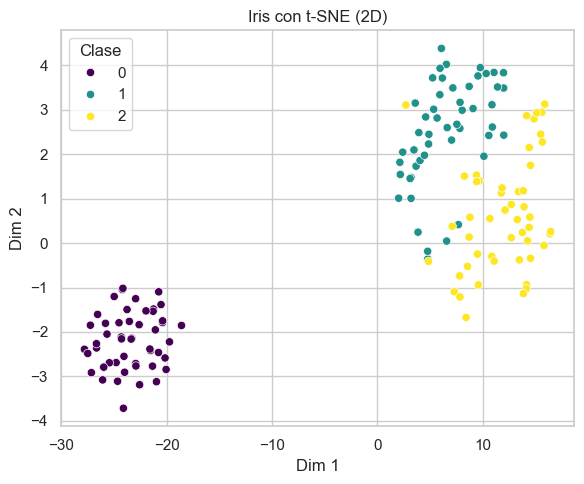

In [5]:
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

plt.figure(figsize=(6,5))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=y, palette='viridis')
plt.title('Iris con t-SNE (2D)')
plt.xlabel('Dim 1')
plt.ylabel('Dim 2')
plt.legend(title='Clase')
plt.tight_layout()
plt.show()

### 5. Espacio para tu conclusión

Escribe aquí tu reflexión comparando PCA y t-SNE para este dataset:
- ¿Qué tan separados se ven los grupos en cada gráfico?
- ¿Cuál te parece más útil para **visualización exploratoria**?
- ¿Cuál usarías si luego quieres alimentar un modelo supervisado?